In [45]:
import os
import sys
import urllib.request

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from stellargraph.layer import GCN_LSTM
import stellargraph as sg
from sklearn import preprocessing

In [2]:
parser = (lambda x:datetime.datetime.strptime(x, '%Y.%m.%d')) 
df = pd.read_csv('sp_beaches_update.csv', parse_dates=['Date'])
df=df.loc[~df['Enterococcus'].isnull()]
#remover a praia do Leste, da cidade de iguape, pois esta praia sumiu por erosão em 2012
#remover a Lagoa Prumirim, da cidade de Ubatuba, pois esta praia possui somente 3 medições
df = df.loc[df['Beach']!='DO LESTE'].loc[df['Beach']!='LAGOA PRUMIRIM']
#seleciona somente os dados de UBATUBA
df = df.loc[df['City']=='UBATUBA']
df['praia'] = df[['City', 'Beach']].apply(lambda x: ' - '.join(x), axis=1)
print(f'Numero de praias: {len(df.praia.unique())}')
df = df.sort_values(by=['praia'])
df = df.sort_values(by=['Date'])
df = df[['Date','praia','Enterococcus']]
df.shape

Numero de praias: 26


(10368, 3)

In [3]:
for praia in df.praia.unique():
    df_aux = df.loc[df['praia']==praia]
    #print(f'Praia: {praia} - Qtd Medições: {len(df_aux.Date)}')
    print(praia)

UBATUBA - IPEROIG
UBATUBA - VERMELHA
UBATUBA - PULSO
UBATUBA - GRANDE
UBATUBA - SANTA RITA
UBATUBA - PEREQUÊ-AÇU
UBATUBA - MARANDUBA
UBATUBA - SUNUNGA
UBATUBA - PRUMIRIM
UBATUBA - TONINHAS
UBATUBA - ENSEADA
UBATUBA - RIO  ITAMAMBUCA
UBATUBA - DURA
UBATUBA - LÁZARO
UBATUBA - VERMELHA DO NORTE
UBATUBA - ITAGUA (No1724 DA AV. LEOVEGILDO)
UBATUBA - FÉLIX
UBATUBA - ITAGUÁ (No 230 DA AV. LEOVEGILDO)
UBATUBA - TENÓRIO
UBATUBA - PICINGUABA
UBATUBA - LAGOINHA (CAMPING)
UBATUBA - SAPÉ
UBATUBA - ITAMAMBUCA
UBATUBA - DOMINGAS DIAS
UBATUBA - LAGOINHA (R. ENGENHO VELHO)
UBATUBA - PEREQUÊ-MIRIM


In [4]:
df_aux=df.pivot(index='praia', columns='Date', values='Enterococcus' )
df_aux.fillna(df_aux.mean(), inplace=True)
df_aux=df_aux.astype('int32')
df_aux
#d = {'praia': [praia]}
#df_novo = pd.DataFrame(data=d) 
#pd.concat([df_novo, df_aux['Enterococcus']], axis=1)
#df_novo = df_novo.join(df_aux['Enterococcus'].T)
#df_novo

Date,2012-01-03,2012-01-08,2012-01-15,2012-01-22,2012-01-29,2012-02-05,2012-02-12,2012-02-19,2012-02-26,2012-03-04,...,2020-07-27,2020-08-03,2020-08-10,2020-08-17,2020-08-24,2020-08-31,2020-09-07,2020-09-14,2020-09-21,2020-09-28
praia,,,,,,,,,,,,,,,,,,,,,
UBATUBA - DOMINGAS DIAS,1,2,360,14,24,1,2,7,1,3,...,39,12,15,64,14,29,29,18,209,47
UBATUBA - DURA,2,108,45,1,8,1,96,1,2,1,...,39,12,15,64,14,29,29,18,209,47
UBATUBA - ENSEADA,61,120,116,24,92,55,72,47,45,44,...,21,3,1,18,1,3,3,1,248,38
UBATUBA - FÉLIX,7,10,9,17,3,4,7,4,2,5,...,39,12,15,64,14,29,29,18,209,47
UBATUBA - GRANDE,5,42,92,16,9,3,10,17,49,15,...,3,2,1,3,2,2,17,14,120,16
UBATUBA - IPEROIG,29,32,336,6,21,4,83,11,29,1,...,39,12,15,64,14,29,29,18,209,47
UBATUBA - ITAGUA (No1724 DA AV. LEOVEGILDO),69,104,136,31,144,140,208,172,52,14,...,39,12,15,64,14,29,29,18,209,47
UBATUBA - ITAGUÁ (No 230 DA AV. LEOVEGILDO),7,26,27,9,120,7,136,16,25,176,...,39,12,15,64,14,29,29,18,209,47
UBATUBA - ITAMAMBUCA,4,16,9,6,10,1,20,1,1,64,...,19,16,2,4,1,1,1,1,124,44


In [5]:
def train_test_split(data, train_portion):
    time_len = data.shape[1]
    train_size = int(time_len * train_portion)
    train_data = np.array(data.iloc[:, :train_size])
    test_data = np.array(data.iloc[:, train_size:])
    return train_data, test_data

In [6]:
train_rate = 0.9
train_data, test_data = train_test_split(df_aux, train_rate)
print("Train data: ", train_data.shape)
print("Test data: ", test_data.shape)

Train data:  (26, 386)
Test data:  (26, 43)


In [7]:
def scale_data(train_data, test_data):
    max_speed = train_data.max()
    min_speed = train_data.min()
    train_scaled = (train_data - min_speed) / (max_speed - min_speed)
    test_scaled = (test_data - min_speed) / (max_speed - min_speed)
    return train_scaled, test_scaled

In [8]:
train_scaled, test_scaled = scale_data(train_data, test_data)
print("Train data: ", train_scaled.shape)
print("Test data: ", test_scaled.shape)

Train data:  (26, 386)
Test data:  (26, 43)


In [9]:
seq_len = 12
pre_len = 10


In [10]:
def sequence_data_preparation(seq_len, pre_len, train_data, test_data):
    trainX, trainY, testX, testY = [], [], [], []

    for i in range(train_data.shape[1] - int(seq_len + pre_len - 1)):
        a = train_data[:, i : i + seq_len + pre_len]
        trainX.append(a[:, :seq_len])
        trainY.append(a[:, -1])

    for i in range(test_data.shape[1] - int(seq_len + pre_len - 1)):
        b = test_data[:, i : i + seq_len + pre_len]
        testX.append(b[:, :seq_len])
        testY.append(b[:, -1])

    trainX = np.array(trainX)
    trainY = np.array(trainY)
    testX = np.array(testX)
    testY = np.array(testY)

    return trainX, trainY, testX, testY

In [11]:
trainX, trainY, testX, testY = sequence_data_preparation(
    seq_len, pre_len, train_scaled, test_scaled
)
print(trainX.shape)
print(trainY.shape)
print(testX.shape)
print(testY.shape)

(365, 26, 12)
(365, 26)
(22, 26, 12)
(22, 26)


In [95]:
#adj_praias = np.ones((trainX.shape[1],trainX.shape[1]))
#adj_praias.shape
df_adj_praias = pd.read_csv('adj_praias.csv',header=None)
df_adj_praias = df_adj_praias.iloc[1:,1:]
min_max_scaler = preprocessing.MinMaxScaler()
praias_scaled = min_max_scaler.fit_transform(df_adj_praias.values)
df_adj_praias = pd.DataFrame(praias_scaled)
df_adj_praias = df_adj_praias.transform(lambda x: 1-x)
df_adj_praias.fillna(0, inplace=True)
adj_praias=df_adj_praias.values
adj_praias

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 4.87804878e-01, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00

In [96]:
gcn_lstm = GCN_LSTM(
    seq_len=seq_len,
    adj=adj_praias,
    gc_layer_sizes=[16, 10],
    gc_activations=["relu", "relu"],
    lstm_layer_sizes=[200, 200],
    lstm_activations=["tanh", "tanh"],
)

C:\Users\User\anaconda3\envs\StellarGraph-gpu\lib\site-packages\ipykernel_launcher.py:7: ExperimentalWarning: GCN_LSTM is experimental: Lack of unit tests and code refinement (see: https://github.com/stellargraph/stellargraph/issues/1132, https://github.com/stellargraph/stellargraph/issues/1526, https://github.com/stellargraph/stellargraph/issues/1564). It may be difficult to use and may have major changes at any time.
  import sys


In [30]:
x_input, x_output = gcn_lstm.in_out_tensors()
model = Model(inputs=x_input, outputs=x_output)
model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 26, 12)]          0         
_________________________________________________________________
tf_op_layer_ExpandDims_1 (Te [(None, 26, 12, 1)]       0         
_________________________________________________________________
reshape_3 (Reshape)          (None, 26, 12)            0         
_________________________________________________________________
fixed_adjacency_graph_convol (None, 26, 16)            894       
_________________________________________________________________
fixed_adjacency_graph_convol (None, 26, 10)            862       
_________________________________________________________________
reshape_4 (Reshape)          (None, 26, None, 1)       0         
_________________________________________________________________
permute_1 (Permute)          (None, None, 26, 1)       0   

In [31]:
model.compile(optimizer="adam", loss="mae", metrics=["mse"])

In [32]:
with tf.device('/GPU:0'): 
    history = model.fit(
        trainX,
        trainY,
        epochs=100,
        batch_size=60,
        shuffle=True,
        verbose=1,
        validation_data=[testX, testY],
    )
history

Train on 365 samples, validate on 22 samples
Epoch 1/100
365/365 [==============================] - 3s 9ms/sample - loss: 0.4261 - mse: 0.1877 - val_loss: 0.2022 - val_mse: 0.0504
Epoch 2/100
365/365 [==============================] - 0s 143us/sample - loss: 0.1139 - mse: 0.0263 - val_loss: 0.0305 - val_mse: 0.0074
Epoch 3/100
365/365 [==============================] - 0s 144us/sample - loss: 0.0312 - mse: 0.0050 - val_loss: 0.0284 - val_mse: 0.0076
Epoch 4/100
365/365 [==============================] - 0s 139us/sample - loss: 0.0233 - mse: 0.0039 - val_loss: 0.0291 - val_mse: 0.0077
Epoch 5/100
365/365 [==============================] - 0s 139us/sample - loss: 0.0221 - mse: 0.0039 - val_loss: 0.0294 - val_mse: 0.0077
Epoch 6/100
365/365 [==============================] - 0s 139us/sample - loss: 0.0216 - mse: 0.0039 - val_loss: 0.0294 - val_mse: 0.0076
Epoch 7/100
365/365 [==============================] - 0s 142us/sample - loss: 0.0217 - mse: 0.0039 - val_loss: 0.0294 - val_mse: 0.007

365/365 [==============================] - 0s 141us/sample - loss: 0.0209 - mse: 0.0037 - val_loss: 0.0287 - val_mse: 0.0074
Epoch 61/100
365/365 [==============================] - 0s 148us/sample - loss: 0.0211 - mse: 0.0038 - val_loss: 0.0288 - val_mse: 0.0075
Epoch 62/100
365/365 [==============================] - 0s 139us/sample - loss: 0.0210 - mse: 0.0038 - val_loss: 0.0289 - val_mse: 0.0075
Epoch 63/100
365/365 [==============================] - 0s 139us/sample - loss: 0.0209 - mse: 0.0037 - val_loss: 0.0290 - val_mse: 0.0075
Epoch 64/100
365/365 [==============================] - 0s 137us/sample - loss: 0.0209 - mse: 0.0037 - val_loss: 0.0290 - val_mse: 0.0075
Epoch 65/100
365/365 [==============================] - 0s 143us/sample - loss: 0.0209 - mse: 0.0038 - val_loss: 0.0289 - val_mse: 0.0075
Epoch 66/100
365/365 [==============================] - 0s 145us/sample - loss: 0.0210 - mse: 0.0037 - val_loss: 0.0288 - val_mse: 0.0074
Epoch 67/100
365/365 [=========================

In [33]:
print(
    "Train loss: ",
    history.history["loss"][-1],
    "\nTest loss:",
    history.history["val_loss"][-1],
)

Train loss:  0.02055865026091876 
Test loss: 0.028551356866955757


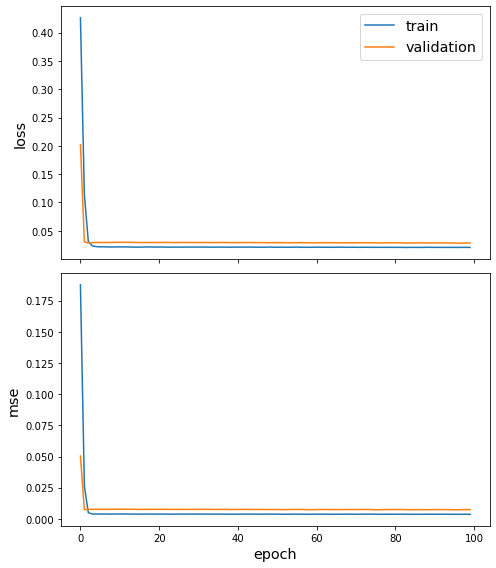

In [34]:
sg.utils.plot_history(history)

In [35]:
ythat = model.predict(trainX)
yhat = model.predict(testX)
print(ythat.shape)
print(yhat.shape)

(365, 26)
(22, 26)


In [36]:
## Rescale values
max_esterococos = train_data.max()
min_esterococos = train_data.min()

## actual train and test values
train_rescref = np.array(trainY * max_esterococos)
test_rescref = np.array(testY * max_esterococos)

In [37]:
train_rescpred = np.array((ythat) * max_esterococos)
test_rescpred = np.array((yhat) * max_esterococos)

In [38]:
testnpred = np.array(testX)[
    :, :, -1
]  # picking the last speed of the 10 sequence for each segment in each sample
testnpredc = (testnpred) * max_esterococos

In [39]:
## Performance measures

seg_mael = []
seg_masel = []
seg_nmael = []

for j in range(testX.shape[-1]):

    seg_mael.append(
        np.mean(np.abs(test_rescref.T[j] - test_rescpred.T[j]))
    )  # Mean Absolute Error for NN
    seg_nmael.append(
        np.mean(np.abs(test_rescref.T[j] - testnpredc.T[j]))
    )  # Mean Absolute Error for naive prediction
    if seg_nmael[-1] != 0:
        seg_masel.append(
            seg_mael[-1] / seg_nmael[-1]
        )  # Ratio of the two: Mean Absolute Scaled Error
    else:
        seg_masel.append(np.NaN)

print("Total (ave) MAE for NN: " + str(np.mean(np.array(seg_mael))))
print("Total (ave) MAE for naive prediction: " + str(np.mean(np.array(seg_nmael))))
print(
    "Total (ave) MASE for per-segment NN/naive MAE: "
    + str(np.nanmean(np.array(seg_masel)))
)
print(
    "...note that MASE<1 (for a given segment) means that the NN prediction is better than the naive prediction."
)

Total (ave) MAE for NN: 57.8343640395087
Total (ave) MAE for naive prediction: 87.20281092264612
Total (ave) MASE for per-segment NN/naive MAE: 0.7547570603901382
...note that MASE<1 (for a given segment) means that the NN prediction is better than the naive prediction.


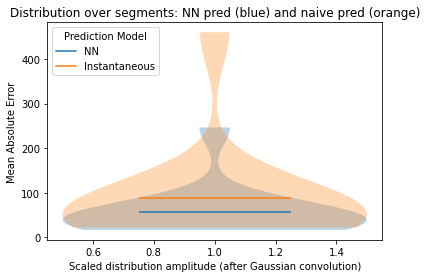

In [40]:
# plot violin plot of MAE for naive and NN predictions
fig, ax = plt.subplots()
# xl = minsl

ax.violinplot(
    list(seg_mael), showmeans=True, showmedians=False, showextrema=False, widths=1.0
)

ax.violinplot(
    list(seg_nmael), showmeans=True, showmedians=False, showextrema=False, widths=1.0
)

line1 = mlines.Line2D([], [], label="NN")
line2 = mlines.Line2D([], [], color="C1", label="Instantaneous")

ax.set_xlabel("Scaled distribution amplitude (after Gaussian convolution)")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Distribution over segments: NN pred (blue) and naive pred (orange)")
plt.legend(handles=(line1, line2), title="Prediction Model", loc=2)
plt.show()

[4.926326  4.926284  4.926471  4.9264407 4.9264026 4.9261994 4.9263353
 4.9263353 4.9263306 4.926408  4.9264054 4.926436  4.9262934 4.9263515
 4.9263024 4.9263563 4.926244  4.926248  4.926658  4.9263396 4.926471
 4.9265337]


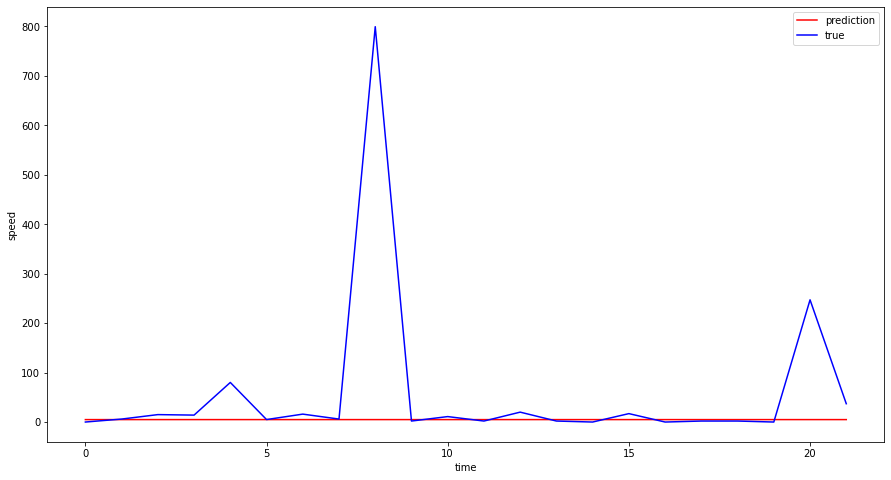

In [42]:
##all test result visualization
fig1 = plt.figure(figsize=(15, 8))
#    ax1 = fig1.add_subplot(1,1,1)
a_pred = test_rescpred[:, 2]
print(a_pred)
a_true = test_rescref[:, 2]
plt.plot(a_pred, "r-", label="prediction")
plt.plot(a_true, "b-", label="true")
plt.xlabel("time")
plt.ylabel("speed")
plt.legend(loc="best", fontsize=10)
plt.show()